# 05: Stability

*How robust is the KG's predictive signal under edge loss?*

This notebook evaluates **stability** across all loaded KGs. Network robustness quantifies how well Adamic-Adar entity-pair rankings are preserved under systematic edge removal — a proxy for resilience to the inherent incompleteness of real-world KGs. If predictive signal is well-distributed across the graph, rankings should be largely preserved even after substantial edge removal. Fragile rankings indicate over-reliance on a sparse set of structurally critical edges.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Random-dropout stability** | Preservation of Adamic-Adar rankings under uniform random edge removal | Spearman *r* at each dropout rate (5%, 10%, 20%) reported to show degradation profile; **10% is the pre-specified primary operating point** | CLES: (*r*₁₀ + 1) / 2 at 10% dropout |
| **Periphery-dropout stability** | Same, but edges incident to lowest-degree nodes removed first (static ordering) | Spearman *r* at each dropout rate (5%, 10%, 20%); **10% is the pre-specified primary operating point** | CLES: (*r*₁₀ + 1) / 2 at 10% dropout |

**Primary operating point.** 10% edge dropout is pre-specified as the primary reporting point, representing a moderate incompleteness regime consistent with estimates of missing edges in published biomedical KGs (Paulheim, 2017). The full degradation curve across 5%, 10%, and 20% is shown in the stability figure and exported to `results/stability/stability.csv`.

**Additional metric.** Top-K overlap (K = 100) is computed for characterisation but does not enter the dimension score.

**Thresholds** (interpretive, not used in scoring): Spearman *r* > 0.95 at 10% random dropout = high stability; *r* < 0.85 = fragile topology.

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`)

**Outputs:** `results/figures/05_stability.{pdf,png}` · `results/stability/stability.csv` · `results/checkpoints/05_stability.pkl`

**Dependencies:** `src/loading.py` · `src/graph_utils.py` · `src/scoring.py` · `src/plotting.py`

## Set-up

In [8]:
# Imports
import sys, os, warnings, math, pickle
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from scipy import stats

from src.plotting    import setup_style, clean_ax, save_fig, panel_label, TEXT_COLOR, OI_SKY_BLUE, KG_PALETTE
from src.loading     import find_config, load_config, load_kg
from src.graph_utils import build_graph, build_lookup_maps
from src.scoring     import score_adamic_adar

setup_style()

In [9]:
# Config and paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';   FIGS.mkdir(parents=True, exist_ok=True)

# Spine styling helper (used in stability plots)
PANEL_SPINE_STYLE = {'lw': 1.4, 'color': TEXT_COLOR}

def _style_left_spine(ax) -> None:
    '''Keep only left spine visible with house style.'''
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].update(PANEL_SPINE_STYLE)

In [10]:
# Free any KG/graph state left over from a previous notebook (prevents
# the ~150 GB OOM that hit when running notebooks back-to-back in one kernel).
for _v in ('kgs', 'graphs', 'maps', 'preps'):
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()

# Load KGs
KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

kgs, graphs, maps = {}, {}, {}
for name in KG_NAMES:
    try:
        kg, nodes    = load_kg(name, config)
        G            = build_graph(kg, nodes)
        kgs[name]    = {'kg': kg, 'nodes': nodes}
        graphs[name] = G
        maps[name]   = build_lookup_maps(nodes)
        print(f'{name:12s}: {G.number_of_nodes():>8,} nodes  {G.number_of_edges():>10,} edges')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

LOADED = [n for n in KG_NAMES if n in graphs and config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :  129,375 nodes   4,049,642 edges
hetionet    :   47,031 nodes   2,107,709 edges
drkg        :   97,238 nodes   4,400,766 edges
openbilink  :  185,929 nodes   3,200,327 edges
biokg       :  105,524 nodes   2,043,846 edges
  matrix: loading from cache _cache_matrix_88f004a4_kg.parquet / _cache_matrix_88f004a4_nodes.parquet
  matrix: cached load — 2,850,122 nodes, 41,595,079 edges
matrix      : 2,850,122 nodes  25,605,352 edges

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg', 'matrix']


## Therapeutic pair extraction

Stability is measured over Adamic-Adar rankings of **known therapeutic (drug–disease) pairs only** — not a mix of positives and random negatives. This design choice ensures we measure the stability of the KG's *biological signal* rather than the stability of a heuristic's ability to separate positives from noise. If known drug–disease pair rankings are preserved under edge dropout, the underlying biological connectivity structure is robust. Negative pairs are excluded because their score instability is uninformative — a random pair's score *should* change under perturbation.

Random negative pairs are still used to establish the baseline score distribution for context, but only known-pair rankings enter the Spearman correlation.

In [11]:
# Entity type sets and LCC computation
DRUG_TYPES    = {'drug', 'Compound', 'compound', 'Drug'}  # 'Drug' for OpenBioLink
DISEASE_TYPES = {'disease', 'Disease'}

lcc_sets = {
    name: sorted(nx.connected_components(graphs[name]), key=len, reverse=True)[0]
    for name in LOADED
}

In [12]:
# Therapeutic pair config - relation filters per KG
KG_THERAPEUTIC = {
    'primekg':  {'mode': 'exact',   'relations': {'indication'}},
    'hetionet': {'mode': 'exact',   'relations': {'CtD'}},
    'drkg':       {'mode': 'pattern', 'pattern':   'treat|indication'},
    # OpenBioLink: DIS_DRUG is the sole drug-disease relation
    'openbilink': {'mode': 'exact',   'relations': {'DIS_DRUG'}},
    # BioKG: DRUG_DISEASE_ASSOCIATION is the therapeutic relation
    'biokg':      {'mode': 'exact',   'relations': {'DRUG_DISEASE_ASSOCIATION'}},
    # MATRIX: treats_or_applied_or_studied_to_treat is the dominant indication predicate (Every Cure scoring)
    'matrix':     {'mode': 'exact',   'relations': {'treats_or_applied_or_studied_to_treat'}},
}

def _relation_mask(kg: pd.DataFrame, cfg: dict) -> pd.Series:
    if cfg['mode'] == 'exact':
        return kg['relation'].isin(cfg['relations'])
    if cfg['mode'] == 'pattern':
        mask = kg['relation'].str.lower().str.contains(cfg['pattern'], na=False)
        if 'x_type' in kg.columns:
            mask &= kg['x_type'].isin(DRUG_TYPES | DISEASE_TYPES)
        return mask
    raise ValueError(f'Unknown mode: {cfg["mode"]}')


def extract_therapeutic_pairs(name: str) -> list:
    cfg = KG_THERAPEUTIC.get(name)
    if cfg is None:
        return []
    kg, lcc = kgs[name]['kg'], lcc_sets[name]
    sub = (kg[_relation_mask(kg, cfg)][['x_index', 'y_index', 'x_type', 'y_type']]
           .astype({'x_index': int, 'y_index': int}))
    sub = sub[sub['x_index'].isin(lcc) & sub['y_index'].isin(lcc)]
    fwd = sub[sub['x_type'].isin(DRUG_TYPES) & sub['y_type'].isin(DISEASE_TYPES)]
    rev = sub[sub['y_type'].isin(DRUG_TYPES) & sub['x_type'].isin(DISEASE_TYPES)]
    return list(set(
        list(zip(fwd['x_index'], fwd['y_index'])) +
        list(zip(rev['y_index'], rev['x_index']))
    ))


def build_negative_pairs(name: str, pos_set: set, n_sample: int, rng) -> list:
    lcc           = lcc_sets[name]
    G             = graphs[name]
    drug_nodes    = [v for v in lcc if G.nodes[v].get('node_type') in DRUG_TYPES]
    disease_nodes = [v for v in lcc if G.nodes[v].get('node_type') in DISEASE_TYPES]
    if not drug_nodes or not disease_nodes:
        return []
    neg, attempts = [], 0
    while len(neg) < n_sample and attempts < n_sample * 20:
        d, dis = rng.choice(drug_nodes), rng.choice(disease_nodes)
        if (d, dis) not in pos_set and (dis, d) not in pos_set:
            neg.append((d, dis))
        attempts += 1
    return neg

In [13]:
# Extract therapeutic pairs
rng = np.random.RandomState(params.get('random_seed', 42))

therapeutic_pairs = {}
for name in LOADED:
    tp = extract_therapeutic_pairs(name)
    therapeutic_pairs[name] = tp
    print(f'{name:12s}: {len(tp):,} therapeutic pairs')

primekg     : 9,388 therapeutic pairs
hetionet    : 755 therapeutic pairs
drkg        : 4,968 therapeutic pairs
openbilink  : 7,164 therapeutic pairs
biokg       : 66,867 therapeutic pairs
matrix      : 383,361 therapeutic pairs


## Stability analysis

Two perturbation strategies are applied at dropout rates drawn from `analysis_params.robustness.dropout_rates`:

| Strategy | Description |
|---|---|
| **Random** | Edges removed uniformly at random — baseline robustness |
| **Periphery** | Lowest-degree incident edges removed first — targets structurally fragile periphery |

Spearman *r* > 0.95 at 10 % dropout → high stability; *r* < 0.85 → fragile topology.

### Parameters & helpers

In [14]:
# Robustness parameters
_rob         = params.get('robustness', {})
DROPOUT_RATES = _rob.get('dropout_rates', [0.05, 0.10, 0.20])
SAMPLE_SIZE   = _rob.get('sample_size', 100)
TOP_K         = _rob.get('top_k', 100)
RANDOM_SEED   = params.get('random_seed', 42)

In [15]:
# Stability metric helpers
def _spearman(a: np.ndarray, b: np.ndarray) -> float:
    mask = (a > 0) | (b > 0)
    return stats.spearmanr(a[mask], b[mask]).statistic if mask.sum() > 10 else np.nan

def _top_k_overlap(a: np.ndarray, b: np.ndarray, k: int = TOP_K) -> float:
    return len(set(np.argsort(-a)[:k]) & set(np.argsort(-b)[:k])) / k

def _metrics(G_pert, baseline: np.ndarray, pairs: list) -> tuple:
    pert = np.array(score_adamic_adar(G_pert, pairs))
    return _spearman(baseline, pert), _top_k_overlap(baseline, pert)



### Robustness sweep

In [16]:
# Dropout robustness analysis — known therapeutic pairs only
stab_results = {}

for name in LOADED:
    tp = therapeutic_pairs.get(name)
    if not tp:
        print(f'{name}: no therapeutic pairs, skipping')
        continue

    G          = graphs[name]
    pos_set    = set(tp)
    all_edges  = list(G.edges())
    stab_rng   = np.random.RandomState(RANDOM_SEED)

    # Sample known therapeutic pairs only for stability measurement
    pos_sample = [tp[i] for i in stab_rng.choice(len(tp), min(SAMPLE_SIZE, len(tp)), replace=False)]

    # Negative pairs used only for context (score distribution), not for Spearman r
    neg_sample = build_negative_pairs(name, pos_set, len(pos_sample), stab_rng)

    # All pairs scored for baseline; Spearman r computed on known pairs only
    all_pairs  = pos_sample + neg_sample
    n_pos      = len(pos_sample)
    baseline_all = np.array(score_adamic_adar(G, all_pairs))
    baseline_pos = baseline_all[:n_pos]   # known pairs only

    deg          = dict(G.degree())
    sorted_edges = sorted(all_edges, key=lambda e: min(deg[e[0]], deg[e[1]]))

    print(f'{name}: {n_pos} known pairs (+ {len(neg_sample)} neg for context) | {len(all_edges):,} edges')

    res = {}
    for rate in DROPOUT_RATES:
        n_drop = int(len(all_edges) * rate)

        # Scale-aware dropout: copy-then-mutate is fine for small graphs
        # but each G.copy() on Matrix is ~30 GB. Use subgraph_view (lazy filter)
        # for huge graphs — same semantics, ~constant extra memory.
        if G.number_of_nodes() > 1_000_000:
            rand_drop_idx = stab_rng.choice(len(all_edges), n_drop, replace=False)
            rand_drop_set = frozenset(
                (min(all_edges[i]), max(all_edges[i])) for i in rand_drop_idx)
            G_rand = nx.subgraph_view(
                G,
                filter_edge=lambda u, v: (min(u,v), max(u,v)) not in rand_drop_set)
            periph_drop_set = frozenset(
                (min(e), max(e)) for e in sorted_edges[:n_drop])
            G_periph = nx.subgraph_view(
                G,
                filter_edge=lambda u, v: (min(u,v), max(u,v)) not in periph_drop_set)
        else:
            G_rand = G.copy()
            G_rand.remove_edges_from([all_edges[i]
                                       for i in stab_rng.choice(len(all_edges), n_drop, replace=False)])

            G_periph = G.copy()
            G_periph.remove_edges_from(sorted_edges[:n_drop])

        # Score all pairs but compute Spearman r on known pairs only
        pert_rand_all = np.array(score_adamic_adar(G_rand, all_pairs))
        pert_peri_all = np.array(score_adamic_adar(G_periph, all_pairs))

        pert_rand_pos = pert_rand_all[:n_pos]
        pert_peri_pos = pert_peri_all[:n_pos]

        res[rate] = {
            'random':    {
                'spearman_r': _spearman(baseline_pos, pert_rand_pos),
                'top_k':      _top_k_overlap(baseline_pos, pert_rand_pos),
            },
            'periphery': {
                'spearman_r': _spearman(baseline_pos, pert_peri_pos),
                'top_k':      _top_k_overlap(baseline_pos, pert_peri_pos),
            },
        }
        print(f'  {rate:.0%}  '
              f'rand r={res[rate]["random"]["spearman_r"]:.3f}  '
              f'periph r={res[rate]["periphery"]["spearman_r"]:.3f}')

    stab_results[name] = res
    print()

primekg: 500 known pairs (+ 500 neg for context) | 4,049,642 edges
  5%  rand r=0.996  periph r=0.993
  10%  rand r=0.993  periph r=0.922
  15%  rand r=0.986  periph r=0.846
  20%  rand r=0.977  periph r=0.730
  25%  rand r=0.970  periph r=0.660
  30%  rand r=0.963  periph r=0.624

hetionet: 500 known pairs (+ 500 neg for context) | 2,107,709 edges
  5%  rand r=0.992  periph r=0.992
  10%  rand r=0.978  periph r=0.980
  15%  rand r=0.962  periph r=0.973
  20%  rand r=0.937  periph r=0.951
  25%  rand r=0.939  periph r=0.935
  30%  rand r=0.894  periph r=0.908

drkg: 500 known pairs (+ 500 neg for context) | 4,400,766 edges
  5%  rand r=0.997  periph r=0.942
  10%  rand r=0.990  periph r=0.863
  15%  rand r=0.988  periph r=0.826
  20%  rand r=0.979  periph r=0.772
  25%  rand r=0.973  periph r=0.757
  30%  rand r=0.969  periph r=0.754

openbilink: 500 known pairs (+ 500 neg for context) | 3,200,327 edges
  5%  rand r=0.918  periph r=0.959
  10%  rand r=0.871  periph r=0.707
  15%  rand 

In [17]:
# Free per-KG edge DataFrames now that cell 7 has built the relation
# filters. Downstream cells operate on graphs[name] / maps[name] only;
# keeping the multi-GB pandas DataFrames around just costs memory.
for _name in list(kgs):
    kgs[_name].pop('kg', None)
import gc; gc.collect()
print('Released kgs[*][\'kg\'] DataFrames.')

Released kgs[*]['kg'] DataFrames.


### Visualisation & export

  → Saved: 05_stability.pdf / .png


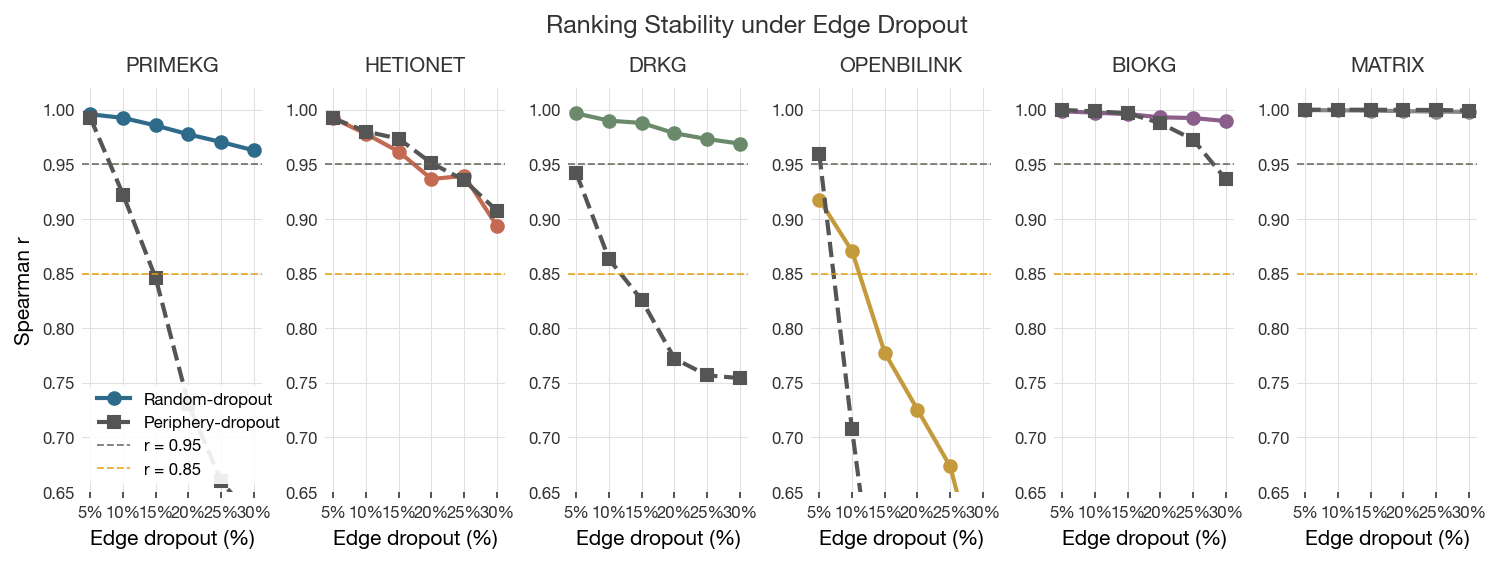

In [18]:
# Ranking stability under edge dropout
STRATEGIES = {
    'random':     ('Random-dropout',   'o-',  None),
    'periphery':  ('Periphery-dropout', 's--', '#555555'),
}

avail_stab   = [n for n in LOADED if n in stab_results]
dropout_pcts = [r * 100 for r in DROPOUT_RATES]

fig, axes = plt.subplots(1, len(avail_stab), figsize=(12, 3.5),
                         gridspec_kw={'wspace': 0.35})
if len(avail_stab) == 1:
    axes = [axes]

for ax, name in zip(axes, avail_stab):
    res = stab_results[name]
    for strategy, (label, style, color) in STRATEGIES.items():
        col   = color or KG_COLORS[name]
        means = [res[r][strategy]['spearman_r'] for r in DROPOUT_RATES]
        ax.plot(dropout_pcts, means, style, color=col, lw=2.0, ms=6, label=label)

    ax.axhline(0.95, color='#655F55', ls='--', lw=0.9, alpha=0.8, label='r = 0.95')
    ax.axhline(0.85, color='#E69F00', ls='--', lw=0.9, alpha=0.8, label='r = 0.85')
    ax.set_xticks(dropout_pcts)
    ax.set_xticklabels([f'{p:.0f}%' for p in dropout_pcts], fontsize=9)
    ax.set_ylim(0.65, 1.02)
    ax.set_ylabel('Spearman r' if ax == axes[0] else '', fontsize=10)
    ax.set_xlabel('Edge dropout (%)', fontsize=10)
    _style_left_spine(ax)
    clean_ax(ax, title=name.upper())
    if ax == axes[0]:
        ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none',
                  framealpha=0.9, loc='lower left')

plt.suptitle('Ranking Stability under Edge Dropout',
             fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '05_stability')
plt.show()

### Checkpoint

In [19]:
# Checkpoint - save scalar stability results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

PRIMARY_DROPOUT = 0.10   # pre-specified primary operating point


def _cles_from_r(r) -> float:
    '''Common Language Effect Size (CLES) from Spearman r.

    Maps r ∈ (-1, 1) to [0, 1] via: CLES = (r + 1) / 2.

    Interpretation: the probability that a randomly drawn known drug–disease
    pair's post-perturbation Adamic-Adar score is ranked consistently with its
    pre-perturbation score. 0.5 = chance-level rank preservation; 1.0 = perfect
    stability.

    This transformation is monotonic and does not change the ranking of KGs —
    it re-expresses the correlation on a probability scale for interpretability.

    Reference: McGraw, K.O. & Wong, S.P. "A common language effect size
    statistic." Psychological Bulletin 111(2), 361–365 (1992).

    Applied to Spearman r computed over *known therapeutic pairs only* at the
    pre-specified 10% primary dropout rate (Paulheim, 2017).
    '''
    return round((r + 1) / 2, 4) if not math.isnan(r) else 0.0


# ── Raw Spearman r per rate (full degradation profile) ────────────────
raw_r = {}
for name in LOADED:
    if name not in stab_results:
        raw_r[name] = {}
        continue
    raw_r[name] = {
        strategy: {rate: stab_results[name][rate][strategy]['spearman_r']
                   for rate in DROPOUT_RATES
                   if rate in stab_results[name]}
        for strategy in STRATEGIES
    }

# ── Sub-scores: CLES at 10% primary dropout rate ──────────────────────
sub_scores     = {}
summary_scores = {}

for name in LOADED:
    if name not in stab_results or PRIMARY_DROPOUT not in stab_results[name]:
        sub_scores[name]     = {'random_stability': 0.0, 'periphery_stability': 0.0}
        summary_scores[name] = 0.0
        continue

    strategy_scores = {}
    for strategy in STRATEGIES:
        r_primary = stab_results[name][PRIMARY_DROPOUT][strategy]['spearman_r']
        strategy_scores[strategy] = _cles_from_r(r_primary)

    sub_scores[name] = {
        'random_stability':    strategy_scores['random'],
        'periphery_stability': strategy_scores['periphery'],
    }
    summary_scores[name] = round(np.mean(list(sub_scores[name].values())), 4)

# ── Print raw degradation profile first, then scores ─────────────────
print(f'Raw Spearman r — full degradation profile (primary = {PRIMARY_DROPOUT:.0%}):\n')
for name in LOADED:
    if name not in stab_results:
        continue
    print(f'  {name.upper()}')
    print(f'  {"Strategy":<22s}  {"5%":>6s}  {"10% *":>7s}  {"20%":>6s}')
    print(f'  ' + '-' * 46)
    for strategy, (label, *_) in STRATEGIES.items():
        rs = [stab_results[name][r][strategy]['spearman_r'] for r in DROPOUT_RATES]
        vals = f'{rs[0]:>6.4f}  {rs[1]:>7.4f}  {rs[2]:>6.4f}'
        print(f'  {label:<22s}  {vals}')
    print()

print(f'Scores (0-1 via CLES at {PRIMARY_DROPOUT:.0%} dropout):')
print(f'{"KG":<12s}  {"Random":>9s}  {"Periphery":>10s}  {"Overall":>9s}')
print('  ' + '-' * 44)
for name in LOADED:
    ss = sub_scores[name]
    print(f'{name:<12s}  {ss["random_stability"]:>9.4f}  '
          f'{ss["periphery_stability"]:>10.4f}  {summary_scores[name]:>9.4f}')

# ── Assemble per-(KG, strategy, rate) records for checkpoint ─────────
avail_stab = [n for n in LOADED if n in stab_results]
stab_df = pd.DataFrame([
    {'KG': name.upper(), 'Strategy': label, 'Dropout': f'{rate:.0%}',
     'Spearman r':    round(stab_results[name][rate][strategy]['spearman_r'], 4),
     'Top-K overlap': round(stab_results[name][rate][strategy]['top_k'], 3)}
    for name in avail_stab
    for strategy, (label, *_) in STRATEGIES.items()
    for rate in DROPOUT_RATES
    if rate in stab_results[name]
])

# ── Save checkpoint ───────────────────────────────────────────────────
ckpt = {
    'summary_scores':  summary_scores,
    'sub_scores':      sub_scores,
    'raw_r':           raw_r,           # full per-rate profile for supplementary
    'primary_dropout': PRIMARY_DROPOUT,
    'stab_scalars': {
        name: {
            rate: {
                strategy: {k: v for k, v in res.get(strategy, {}).items()
                            if isinstance(v, (int, float))}
                for strategy in STRATEGIES
            }
            for rate, res in rates.items()
        }
        for name, rates in stab_results.items()
    },
    'stab_records':  stab_df.to_dict('records') if not stab_df.empty else [],
    'dropout_rates': list(DROPOUT_RATES),
}

out = CKPT_DIR / '05_stability.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)
print(f'\nCheckpoint saved: {out}')

Raw Spearman r — full degradation profile (primary = 10%):

  PRIMEKG
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9958   0.9925  0.9856
  Periphery-dropout       0.9927   0.9224  0.8458

  HETIONET
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9922   0.9779  0.9616
  Periphery-dropout       0.9923   0.9801  0.9735

  DRKG
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9966   0.9900  0.9879
  Periphery-dropout       0.9418   0.8632  0.8258

  OPENBILINK
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9177   0.8707  0.7775
  Periphery-dropout       0.9594   0.7073  0.4821

  BIOKG
  Strategy                    5%    10% *     20%
  ---------------------------------------

## Dimension Score

The stability dimension score combines two sub-metrics:

$$\text{Stability} = \frac{1}{2}\left(\text{Random-Dropout Stability} + \text{Periphery-Dropout Stability}\right)$$

---

**Primary quantification.** Spearman rank correlation $r$ is reported at each dropout rate (5%, 10%, 20%) and for each strategy in the stability curve figure (Fig. 05) and `results/stability/stability.csv`. These per-rate values are the primary evidence for stability claims in the paper.

---

**Scoring.** Each sub-metric uses Spearman $r$ at the **pre-specified primary dropout rate of 10%**, mapped to [0, 1] via the Common Language Effect Size (CLES):

$$\text{Sub-score} = \frac{r_{10\%} + 1}{2} = P(\text{rank preserved at 10\% dropout})$$

10% is pre-specified as the primary operating point, representing a moderate incompleteness regime consistent with estimates of missing edges in published biomedical KGs (Paulheim, 2017). It is sufficiently large to detect genuine fragility while remaining within a realistic range of typical KG incompleteness.

The CLES transformation (McGraw & Wong, 1992) gives a direct probabilistic interpretation: the probability that a randomly drawn post-perturbation score is ranked consistently with the pre-perturbation ranking. A value of 0.5 indicates no rank preservation; 1.0 indicates perfect stability.

The full degradation profile across 5%, 10%, and 20% is stored in `raw_r` in the checkpoint and shown in the stability figure. It serves as supporting evidence that the 10% primary score is representative of the KG's broader stability behaviour.

In [20]:
# Memory cleanup - free state before the next notebook in the pipeline.
# Without this, the kgs / graphs / maps dicts (multi-GB pandas DataFrames
# and NetworkX graphs) stay resident in the kernel; the next notebook then
# re-loads everything on top, which is how we pushed past 150 GB.
_to_free = ['kgs', 'graphs', 'maps', 'preps']
for _v in _to_free:
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()
print('Freed KG state from kernel memory.')

Freed KG state from kernel memory.
